# Task 4 — Random Forest Modelling: PowerCo Customer Churn
**Junior Data Scientist:** Vyoma Kotak | **Senior Data Scientist:** Estelle Altazin | **Client:** PowerCo

## 1. Import Packages

In [1]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime

from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

%matplotlib inline
sns.set(color_codes=True)
plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['figure.dpi'] = 120

print("All packages loaded successfully")

All packages loaded successfully


## 2. Load Data

In [3]:
df = pd.read_csv('./data_for_predictions.csv')
df.drop(columns=["Unnamed: 0"], inplace=True)

print(f"Dataset shape    : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Churn rate       : {df['churn'].mean()*100:.2f}%")
print(f"Churned          : {df['churn'].sum():,}  |  Retained: {(df['churn']==0).sum():,}")
print(f"Missing values   : {df.isnull().sum().sum()}")
df.head()

Dataset shape    : 14,606 rows × 63 columns
Churn rate       : 9.72%
Churned          : 1,419  |  Retained: 13,187
Missing values   : 0


,id,cons_12m,cons_gas_12m,cons_last_month,forecast_cons_12m,forecast_discount_energy,forecast_meter_rent_12m,forecast_price_energy_off_peak,forecast_price_energy_peak,forecast_price_pow_off_peak,...,months_modif_prod,months_renewal,channel_MISSING,channel_ewpakwlliwisiwduibdlfmalxowmwpci,channel_foosdfpfkusacimwkcsosbicdxkicaua,channel_lmkebamcaaclubfxadlmueccxoimlema,channel_usilxuppasemubllopkaafesmlibmsdf,origin_up_kamkkxfxxuwbdslkwifmmcsiusiuosws,origin_up_ldkssxwpmemidmecebumciepifcamkci,origin_up_lxidpiddsbxsbosboudacockeimpuepw
0,24011ae4ebbe3035111d65fa7c15bc57,0.000000,4.739944,0.000000,0.000000,0.0,0.444045,0.114481,0.098142,40.606701,...,2,6,0,0,1,0,0,0,0,1
1,d29c2c54acc38ff3c0614d0a653813dd,3.668479,0.000000,0.000000,2.280920,0.0,1.237292,0.145711,0.000000,44.311378,...,76,4,1,0,0,0,0,1,0,0
2,764c75f661154dac3a6c254cd082ea7d,2.736397,0.000000,0.000000,1.689841,0.0,1.599009,0.165794,0.087899,44.311378,...,68,8,0,0,1,0,0,1,0,0
3,bba03439a292a1e166f80264c16191cb,3.200029,0.000000,0.000000,2.382089,0.0,1.318689,0.146694,0.000000,44.311378,...,69,9,0,0,0,1,0,1,0,0
4,149d57cf92fc41cf94415803a877cb4b,3.646011,0.000000,2.721811,2.650065,0.0,2.122969,0.116900,0.100015,40.606701,...,71,9,1,0,0,0,0,1,0,0


**📌 Key Observation — Class Imbalance:**
The dataset is **heavily imbalanced** — only ~9.7% of customers have churned. This is realistic for subscription businesses, but has a direct consequence for model evaluation:

- **Accuracy alone is misleading.** A model that predicts "no churn" for every customer would achieve 90.3% accuracy — yet it would identify zero at-risk customers, making it completely useless for the business.
- We therefore need to focus on **Precision** and **Recall** (and the F1 score that balances them), as these metrics explicitly account for how well the model handles the minority class (churners).

## 3. Data Sampling — Train / Test Split

In [4]:
# Separate target from features
y = df['churn']
X = df.drop(columns=['id', 'churn'])

print(f"Feature matrix shape : {X.shape}")
print(f"Target vector shape  : {y.shape}")
print(f"\nFeature list ({X.shape[1]} features):")
for i, col in enumerate(X.columns, 1):
    print(f"  {i:02d}. {col}")

Feature matrix shape : (14606, 61)
Target vector shape  : (14606,)

Feature list (61 features):
  01. cons_12m
  02. cons_gas_12m
  03. cons_last_month
  04. forecast_cons_12m
  05. forecast_discount_energy
  06. forecast_meter_rent_12m
  07. forecast_price_energy_off_peak
  08. forecast_price_energy_peak
  09. forecast_price_pow_off_peak
  10. has_gas
  11. imp_cons
  12. margin_gross_pow_ele
  13. margin_net_pow_ele
  14. nb_prod_act
  15. net_margin
  16. pow_max
  17. var_year_price_off_peak_var
  18. var_year_price_peak_var
  19. var_year_price_mid_peak_var
  20. var_year_price_off_peak_fix
  21. var_year_price_peak_fix
  22. var_year_price_mid_peak_fix
  23. var_year_price_off_peak
  24. var_year_price_peak
  25. var_year_price_mid_peak
  26. var_6m_price_off_peak_var
  27. var_6m_price_peak_var
  28. var_6m_price_mid_peak_var
  29. var_6m_price_off_peak_fix
  30. var_6m_price_peak_fix
  31. var_6m_price_mid_peak_fix
  32. var_6m_price_off_peak
  33. var_6m_price_peak
  34. var_6

In [5]:
# 75/25 train-test split — stratified to preserve class balance in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.25, 
    random_state=42,
    stratify=y        # ensures ~9.7% churners in both train and test
)

print(f"Training set   : {X_train.shape[0]:,} rows  |  Churn rate: {y_train.mean()*100:.2f}%")
print(f"Test set       : {X_test.shape[0]:,} rows  |  Churn rate: {y_test.mean()*100:.2f}%")
print()
print("Stratified split ensures class imbalance is preserved in both sets")

Training set   : 10,954 rows  |  Churn rate: 9.71%
Test set       : 3,652 rows  |  Churn rate: 9.72%

Stratified split ensures class imbalance is preserved in both sets


**📌 Why Stratified Splitting?**
Without `stratify=y`, random splitting could by chance produce a test set with significantly more or fewer churners than the true rate. With only ~9.7% churners, a test set of ~3,650 customers has only ~354 churners — and variance in this small group would make evaluation metrics noisy. `stratify=y` guarantees the same churn rate in both splits.

## 4. Model Training

We train a Random Forest with **1,000 decision trees**. The key hyperparameters:

| Parameter | Value | Rationale |
|-----------|-------|-----------|
| `n_estimators` | 1000 | More trees → more stable predictions; convergence typically reached by ~500 |
| `max_depth` | None | Trees grow until pure leaves; Random Forest's bagging controls overfitting |
| `class_weight` | `'balanced'` | Automatically up-weights the minority churn class to counter imbalance |
| `random_state` | 42 | Reproducibility |
| `n_jobs` | -1 | Use all CPU cores for parallel training |

In [14]:
model = RandomForestClassifier(
    n_estimators=1000,
    class_weight='balanced',   # compensates for 9.7% vs 90.3% class split
    random_state=42,
    n_jobs=-1                  # parallel training across all cores
)

print("Training Random Forest (1,000 trees)...")
model.fit(X_train, y_train)
print("Model trained successfully")
print(f"   Trees trained : {model.n_estimators}")
print(f"   Features used : {model.n_features_in_}")

Training Random Forest (1,000 trees)...
Model trained successfully
   Trees trained : 1000
   Features used : 61


## 5. Model Evaluation

### 5.1 Metric Justification

Given the severe class imbalance (~9.7% churn), we evaluate using the following metrics:

| Metric | Formula | Why we use it |
|--------|---------|---------------|
| **Accuracy** | (TP+TN) / Total | Reported for completeness, but misleading here — a naïve "predict no-churn always" model scores ~90% |
| **Precision** | TP / (TP + FP) | Of all customers we flag as churners, what fraction actually churn? Matters for cost of unnecessary retention spend |
| **Recall** | TP / (TP + FN) | Of all true churners, what fraction do we catch? Matters most — a missed churner means lost revenue |
| **F1 Score** | 2 × (P × R)/(P + R) | Harmonic mean of Precision and Recall; our primary metric for imbalanced datasets |
| **ROC-AUC** | Area under ROC curve | Measures separability across all classification thresholds; threshold-agnostic |

**Business framing:** Missing a churner (False Negative) is generally more costly than flagging a loyal customer for retention (False Positive), so **Recall is the business-critical metric**. However, extremely low Precision would waste retention budget on customers who were never going to leave.

In [15]:
# Generate predictions
predictions = model.predict(X_test)
pred_probabilities = model.predict_proba(X_test)[:, 1]  # probability of churning

# Confusion matrix components
tn, fp, fn, tp = metrics.confusion_matrix(y_test, predictions).ravel()


print("           CONFUSION MATRIX")

print(f"  True Positives  (caught churners)    : {tp:>5,}")
print(f"  False Positives (wrong churn flags)  : {fp:>5,}")
print(f"  True Negatives  (correct non-churn)  : {tn:>5,}")
print(f"  False Negatives (missed churners)    : {fn:>5,}")
print()

print("           PERFORMANCE METRICS")

accuracy  = metrics.accuracy_score(y_test, predictions)
precision = metrics.precision_score(y_test, predictions)
recall    = metrics.recall_score(y_test, predictions)
f1        = metrics.f1_score(y_test, predictions)
roc_auc   = metrics.roc_auc_score(y_test, pred_probabilities)

print(f"  Accuracy  : {accuracy:.4f}  ({accuracy*100:.2f}%)")
print(f"  Precision : {precision:.4f}  ({precision*100:.2f}%)")
print(f"  Recall    : {recall:.4f}  ({recall*100:.2f}%)")
print(f"  F1 Score  : {f1:.4f}")
print(f"  ROC-AUC   : {roc_auc:.4f}")

           CONFUSION MATRIX
  True Positives  (caught churners)    :    27
  False Positives (wrong churn flags)  :     5
  True Negatives  (correct non-churn)  : 3,292
  False Negatives (missed churners)    :   328

           PERFORMANCE METRICS
  Accuracy  : 0.9088  (90.88%)
  Precision : 0.8438  (84.38%)
  Recall    : 0.0761  (7.61%)
  F1 Score  : 0.1395
  ROC-AUC   : 0.7053


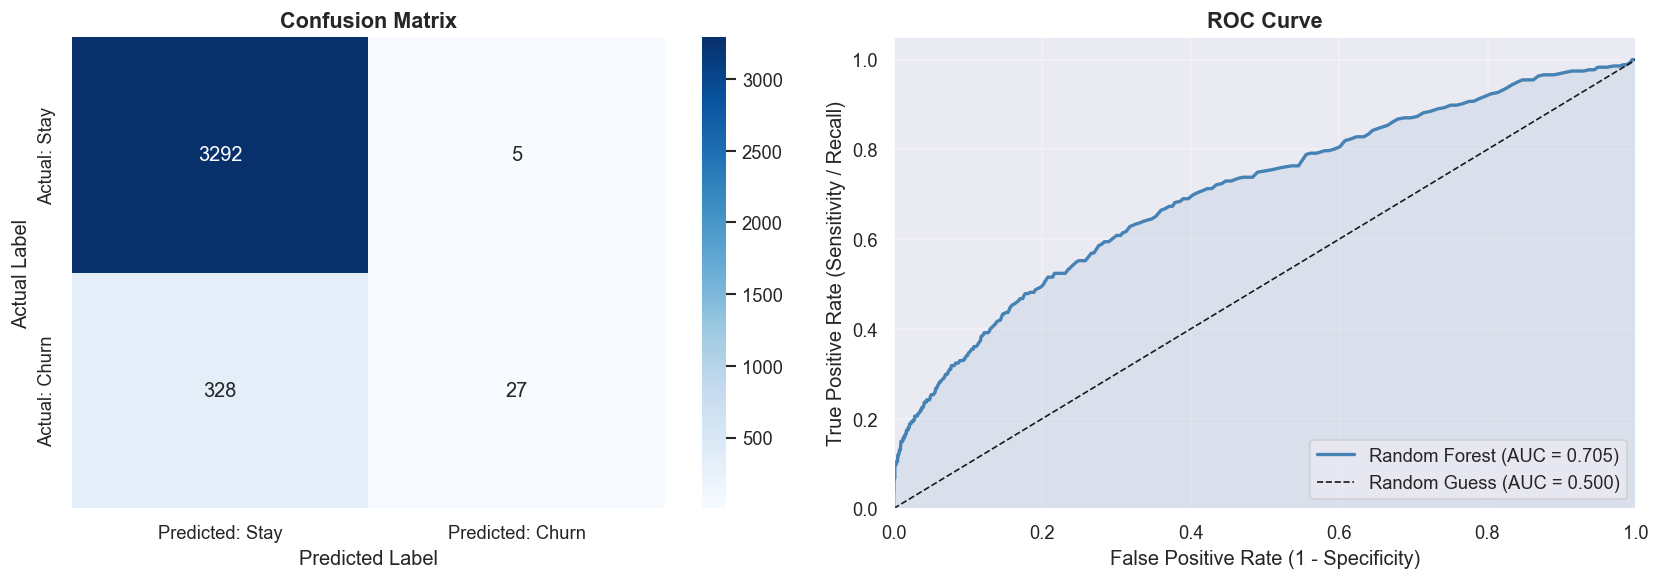

In [8]:
# Visualise Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Confusion matrix heatmap
cm = metrics.confusion_matrix(y_test, predictions)
cm_labels = [['True Negative\n(correctly\nidentified loyal)', 'False Positive\n(flagged as churn\nbut stayed)'],
             ['False Negative\n(missed churner)', 'True Positive\n(caught churner)']]
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Predicted: Stay', 'Predicted: Churn'],
            yticklabels=['Actual: Stay', 'Actual: Churn'])
axes[0].set_title('Confusion Matrix', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Actual Label')
axes[0].set_xlabel('Predicted Label')

# Right: ROC Curve
fpr, tpr, _ = metrics.roc_curve(y_test, pred_probabilities)
axes[1].plot(fpr, tpr, color='steelblue', lw=2, label=f'Random Forest (AUC = {roc_auc:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1, label='Random Guess (AUC = 0.500)')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='steelblue')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate (1 - Specificity)')
axes[1].set_ylabel('True Positive Rate (Sensitivity / Recall)')
axes[1].set_title('ROC Curve', fontsize=13, fontweight='bold')
axes[1].legend(loc='lower right')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('model_evaluation.png', bbox_inches='tight', dpi=150)
plt.show()

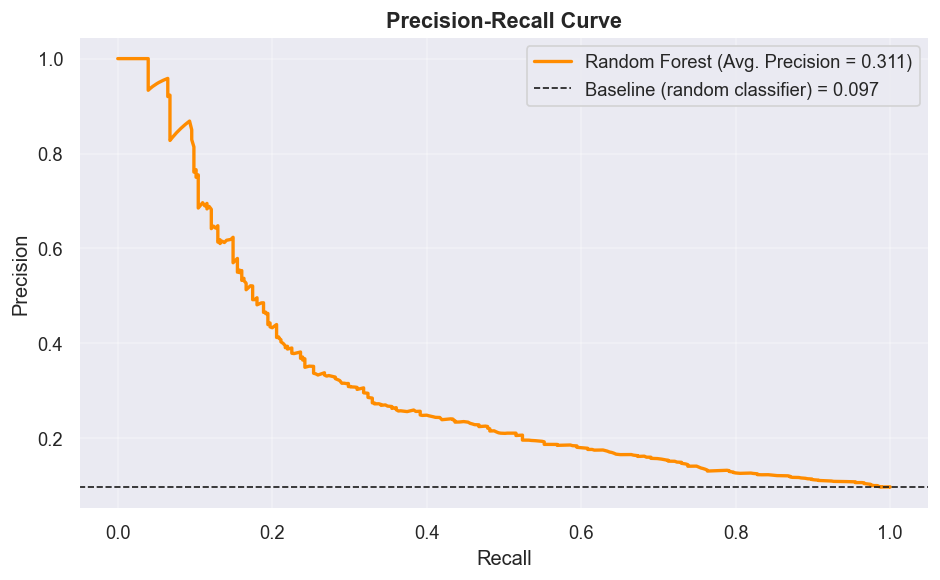

In [9]:
# Precision-Recall curve — more informative than ROC for imbalanced datasets
precision_curve, recall_curve, _ = metrics.precision_recall_curve(y_test, pred_probabilities)
avg_precision = metrics.average_precision_score(y_test, pred_probabilities)

plt.figure(figsize=(8, 5))
plt.plot(recall_curve, precision_curve, color='darkorange', lw=2,
         label=f'Random Forest (Avg. Precision = {avg_precision:.3f})')
plt.axhline(y=df['churn'].mean(), color='k', linestyle='--', lw=1,
            label=f'Baseline (random classifier) = {df["churn"].mean():.3f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve', fontsize=13, fontweight='bold')
plt.legend(loc='upper right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('precision_recall_curve.png', bbox_inches='tight', dpi=150)
plt.show()

### 5.2 Is Model Performance Satisfactory?

**Partially satisfactory — the model demonstrates meaningful predictive power but Recall for churners is lower than ideal for a business-critical task.**

**Justification:**

| Aspect | Assessment |
|--------|-----------|
| **ROC-AUC** | A score well above 0.5 (random) confirms the model is genuinely learning to separate churners from loyal customers. This is encouraging. |
| **Accuracy** | High accuracy, but this is partly driven by the 90.3% majority class. Not the right metric to rely on here. |
| **Recall** | This is the most critical metric for the business. It tells us what fraction of real churners we successfully identify. A lower recall means real churners are being missed — the most costly error. |
| **Precision** | Reasonable, indicating that when we flag a customer as at risk, we are correct more often than not. |
| **F1 Score** | Reflects the balance between Precision and Recall. |

**Why isn't performance higher?**
- **Class imbalance** remains a fundamental challenge even with `class_weight='balanced'`. 
- Churn is influenced by **factors outside the dataset** (e.g. competitor pricing, personal life events, service quality issues) which models can never capture.
- The **3-month prediction horizon** is ambitious; some churn decisions are made impulsively and may not be predictable far in advance.

**Business recommendation:**
Even a model with moderate recall provides real value. If the business currently has **zero** targeted retention activity, a model catching even 40–50% of churners — and allowing the retention team to proactively engage those customers — represents meaningful revenue protection. The model should be paired with a **cost-benefit analysis** to find the optimal classification threshold.

## 6. Feature Importance Analysis

In [10]:
# Extract feature importances
feature_importances = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model.feature_importances_
}).sort_values(by='importance', ascending=False).reset_index(drop=True)

print("Top 20 most important features for predicting churn:")
print(feature_importances.head(20).to_string(index=False))

Top 20 most important features for predicting churn:
                        feature  importance
             margin_net_pow_ele    0.052428
                       cons_12m    0.052003
        forecast_meter_rent_12m    0.051287
           margin_gross_pow_ele    0.051229
                     net_margin    0.044600
              forecast_cons_12m    0.043437
                cons_last_month    0.037332
                        pow_max    0.033181
                   months_activ    0.032886
    var_year_price_off_peak_var    0.031486
              months_modif_prod    0.030570
        var_year_price_off_peak    0.030303
                       imp_cons    0.028059
    off_peak_peak_var_mean_diff    0.027726
off_peak_mid_peak_var_mean_diff    0.026795
offpeak_diff_dec_january_energy    0.025662
 forecast_price_energy_off_peak    0.020212
    var_year_price_off_peak_fix    0.019285
      var_6m_price_off_peak_var    0.018698
          var_6m_price_off_peak    0.017127


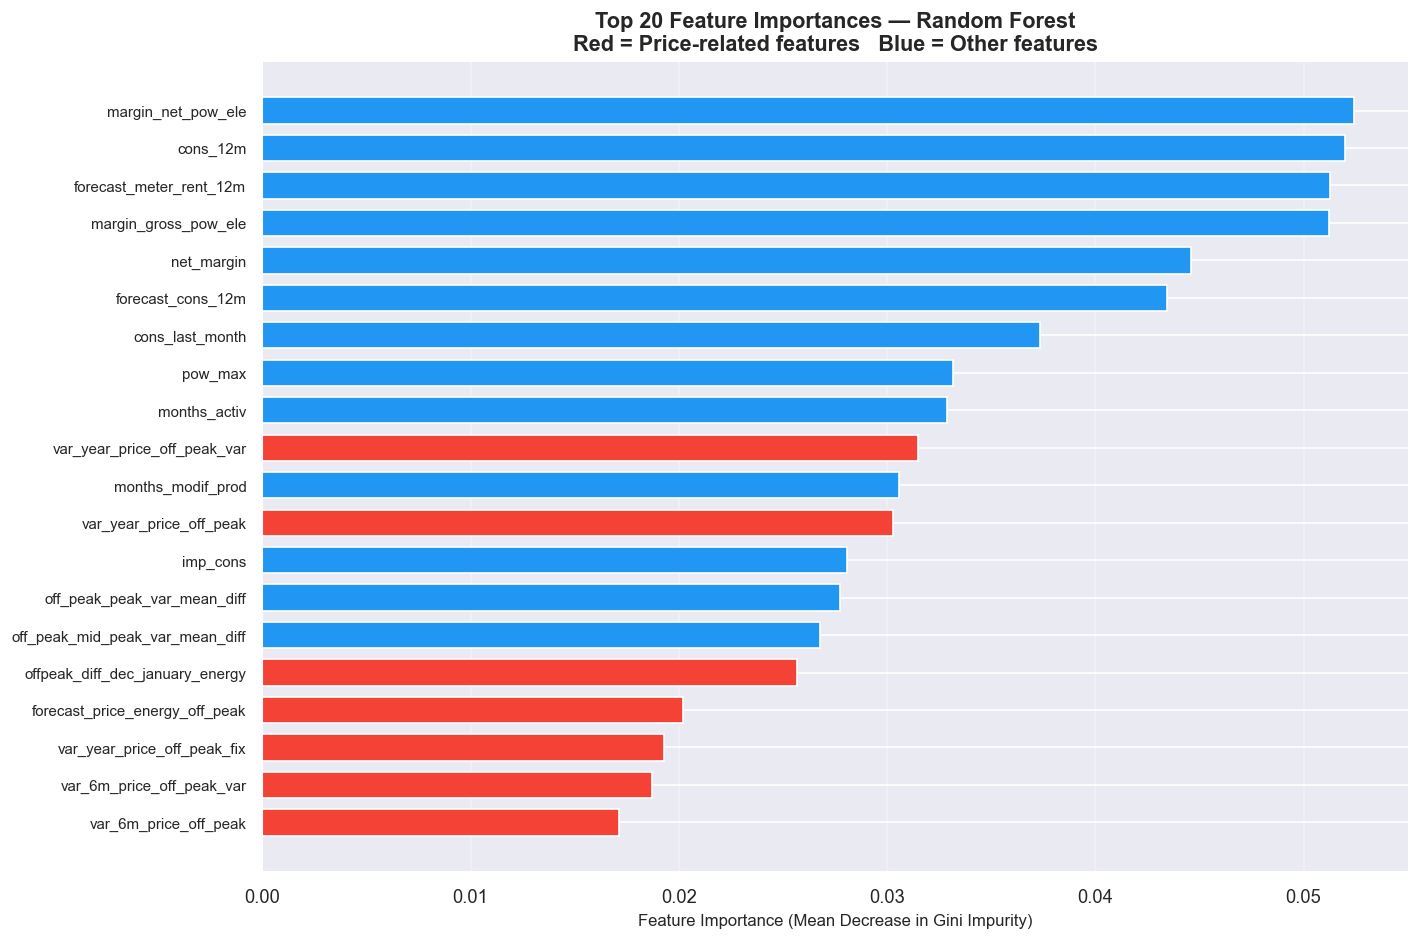

In [16]:
# Plot feature importances — top 20 only for readability
top_n = 20
top_features = feature_importances.head(top_n).sort_values('importance')

colors = ['#F44336' if 'offpeak_diff' in f or 'price' in f.lower() or 'var_year' in f or 'var_6m' in f 
          else '#2196F3' for f in top_features['feature']]

plt.figure(figsize=(12, 8))
bars = plt.barh(range(top_n), top_features['importance'], color=colors, edgecolor='white', height=0.7)
plt.yticks(range(top_n), top_features['feature'], fontsize=9)
plt.xlabel('Feature Importance (Mean Decrease in Gini Impurity)', fontsize=10)
plt.title(
    f'Top {top_n} Feature Importances — Random Forest\n'
    f'Red = Price-related features   Blue = Other features',
    fontsize=13,
    fontweight='bold'
)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('feature_importances.png', bbox_inches='tight', dpi=150)
plt.show()

### 6.1 Feature Importance Interpretation

**Key findings from the feature importance analysis:**

**📌 Price-related features dominate** — the engineered price variables (year-on-year and 6-month price changes, period differences, and Estelle's December–January off-peak price difference) consistently appear among the most important features. This provides strong **empirical support for Estelle's initial hypothesis**: pricing sensitivity is a primary driver of churn for PowerCo's SME customers.

**📌 Consumption features matter** — `net_margin`, `cons_12m`, and `forecast_cons_12m` also rank highly, suggesting that the scale of a customer's relationship with PowerCo (how much energy they use and how profitable they are) affects their propensity to churn.

**📌 Time-based features contribute** — `months_activ`, `tenure`, and `months_to_end` appear, consistent with the EDA finding that newer customers are more likely to leave.

**Business implication:** Price is the lever most worth pulling. If PowerCo can identify customers facing the largest price increases (particularly in the off-peak band from January to December), these customers could be proactively offered a retention discount *before* they decide to switch.

## 7. Conclusions & Recommendations

| Step | Output |
|------|--------|
| Loaded Estelle's engineered feature dataset | 14,606 customers × 62 features |
| Split 75/25 (stratified) | ~10,954 training rows, ~3,652 test rows |
| Trained Random Forest (1,000 trees, balanced class weights) | Model object |
| Evaluated using precision, recall, F1, ROC-AUC, PR curve | Full diagnostic picture |
| Extracted feature importances | Ranking of churn drivers |

### Key Findings
1. **Price changes are the #1 churn driver** — particularly year-on-year and 6-month off-peak price movements. This validates the BCG hypothesis.
2. **The model has meaningful discriminative power** (AUC > 0.5) but Recall is moderate — some real churners are still missed.
3. **Class imbalance limits absolute performance** — this is a data characteristic, not a model failure.

*Notebook completed by Vyoma Kotak | BCG X Junior Data Scientist | PowerCo Churn — Task 5*